<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/timeseries_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [2]:
import pandas as pd

# stock price

gig_stock_df_monthly = pd.read_csv('../../data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('../../data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data

google_df_monthly = pd.read_csv('../../data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data

fred_df_monthly = pd.read_csv('../../data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()

,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [4]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

# Create target variable = close/cpi_data_monthly

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# Create target variable = close/cpi_data_monthly

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [6]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()


/tmp/ipykernel_511/820193813.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_511/820193813.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


In [7]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Herbalife','Primerica','Tupperware','Avon','Etsy','Shopify','Udemy',
                 'Nu skin', 'USANA']

df['CompanyType'] = df['company'].apply(
    lambda x: 'Gig/MLM' if x in gig_companies else 'S&P500'
)

df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S&P500
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,S&P500
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,S&P500
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,S&P500
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,S&P500


In [9]:
time_series_df = df.groupby(['year', 'month']).agg({
    'Close':'mean',
    'SearchInterest': 'mean',
    'unemployment_data_monthly' : 'mean',
    'cpi_data_monthly': 'mean',
    'CompanyType' : 'first'
}).reset_index()

time_series_df.head()

,year,month,Close,SearchInterest,unemployment_data_monthly,cpi_data_monthly,CompanyType
0,2005,1,24.018750,NaN,5.3,191.6,S&P500
1,2005,2,24.417407,NaN,5.4,192.4,S&P500
2,2005,3,23.618066,NaN,5.2,193.1,S&P500
3,2005,4,22.840152,NaN,5.2,193.7,S&P500
4,2005,5,23.876322,NaN,5.1,193.6,S&P500


In [11]:
gig_ts = df[df['CompanyType'] == 'Gig/MLM'].groupby(['year','month']).agg({
    'Close':'mean',
    'SearchInterest':'mean'
}).reset_index()

sp_ts = df[df['CompanyType'] == 'S&P500'].groupby(['year','month']).agg({
    'Close':'mean'
}).reset_index()

gig_ts.head()

,year,month,Close,SearchInterest
0,2005,1,10.812536,NaN
1,2005,2,12.818643,NaN
2,2005,3,13.455857,NaN
3,2005,4,11.948376,NaN
4,2005,5,12.915121,NaN


In [13]:
macro_ts = df.groupby(['year','month']).agg({
    'unemployment_data_monthly':'mean',
    'cpi_data_monthly':'mean'
}).reset_index()

macro_ts.head()

,year,month,unemployment_data_monthly,cpi_data_monthly
0,2005,1,5.3,191.6
1,2005,2,5.4,192.4
2,2005,3,5.2,193.1
3,2005,4,5.2,193.7
4,2005,5,5.1,193.6


In [22]:
ts = gig_ts.merge(sp_ts, on=['year','month'], suffixes=('_Gig','_SP'))
ts = ts.merge(macro_ts, on=['year','month'])

ts

,year,month,Close_Gig,SearchInterest,Close_SP,unemployment_data_monthly,cpi_data_monthly
0,2005,1,10.812536,NaN,24.086999,5.3,191.600
1,2005,2,12.818643,NaN,24.477349,5.4,192.400
2,2005,3,13.455857,NaN,23.670584,5.2,193.100
3,2005,4,11.948376,NaN,22.896295,5.2,193.700
4,2005,5,12.915121,NaN,23.932823,5.1,193.600
...,...,...,...,...,...,...,...
247,2025,8,80.088977,22.978022,225.567596,4.3,323.291
248,2025,9,84.838165,21.576923,227.986886,4.4,324.245
249,2025,10,82.432515,22.029777,224.209117,NaN,NaN
250,2025,11,75.678300,23.673077,227.692907,4.5,325.063


In [25]:
ts['time'] = ts['year'].astype(str) + ' M' + ts['month'].astype(str)
ts

,year,month,Close_Gig,SearchInterest,Close_SP,unemployment_data_monthly,cpi_data_monthly,Gig_norm,SP_norm,Search_norm,Unemployment_norm,time
0,2005,1,10.812536,NaN,24.086999,5.3,191.600,1.000000,1.000000,NaN,1.000000,2005 M1
1,2005,2,12.818643,NaN,24.477349,5.4,192.400,1.185535,1.016206,NaN,1.018868,2005 M2
2,2005,3,13.455857,NaN,23.670584,5.2,193.100,1.244468,0.982712,NaN,0.981132,2005 M3
3,2005,4,11.948376,NaN,22.896295,5.2,193.700,1.105048,0.950567,NaN,0.981132,2005 M4
4,2005,5,12.915121,NaN,23.932823,5.1,193.600,1.194458,0.993599,NaN,0.962264,2005 M5
...,...,...,...,...,...,...,...,...,...,...,...,...
247,2025,8,80.088977,22.978022,225.567596,4.3,323.291,7.407048,9.364703,11.489011,0.811321,2025 M8
248,2025,9,84.838165,21.576923,227.986886,4.4,324.245,7.846278,9.465143,10.788462,0.830189,2025 M9
249,2025,10,82.432515,22.029777,224.209117,NaN,NaN,7.623791,9.308304,11.014888,NaN,2025 M10
250,2025,11,75.678300,23.673077,227.692907,4.5,325.063,6.999126,9.452938,11.836538,0.849057,2025 M11


In [26]:
# Normalize variables

ts['Gig_norm'] = ts['Close_Gig'] / ts['Close_Gig'].iloc[0]
ts['SP_norm'] = ts['Close_SP'] / ts['Close_SP'].iloc[0]
ts['Search_norm'] = ts['SearchInterest'] / ts['SearchInterest'].dropna().iloc[0]
ts['Unemployment_norm'] = ts['unemployment_data_monthly'] / ts['unemployment_data_monthly'].iloc[0]

ts

,year,month,Close_Gig,SearchInterest,Close_SP,unemployment_data_monthly,cpi_data_monthly,Gig_norm,SP_norm,Search_norm,Unemployment_norm,time
0,2005,1,10.812536,NaN,24.086999,5.3,191.600,1.000000,1.000000,NaN,1.000000,2005 M1
1,2005,2,12.818643,NaN,24.477349,5.4,192.400,1.185535,1.016206,NaN,1.018868,2005 M2
2,2005,3,13.455857,NaN,23.670584,5.2,193.100,1.244468,0.982712,NaN,0.981132,2005 M3
3,2005,4,11.948376,NaN,22.896295,5.2,193.700,1.105048,0.950567,NaN,0.981132,2005 M4
4,2005,5,12.915121,NaN,23.932823,5.1,193.600,1.194458,0.993599,NaN,0.962264,2005 M5
...,...,...,...,...,...,...,...,...,...,...,...,...
247,2025,8,80.088977,22.978022,225.567596,4.3,323.291,7.407048,9.364703,11.489011,0.811321,2025 M8
248,2025,9,84.838165,21.576923,227.986886,4.4,324.245,7.846278,9.465143,10.788462,0.830189,2025 M9
249,2025,10,82.432515,22.029777,224.209117,NaN,NaN,7.623791,9.308304,11.014888,NaN,2025 M10
250,2025,11,75.678300,23.673077,227.692907,4.5,325.063,6.999126,9.452938,11.836538,0.849057,2025 M11


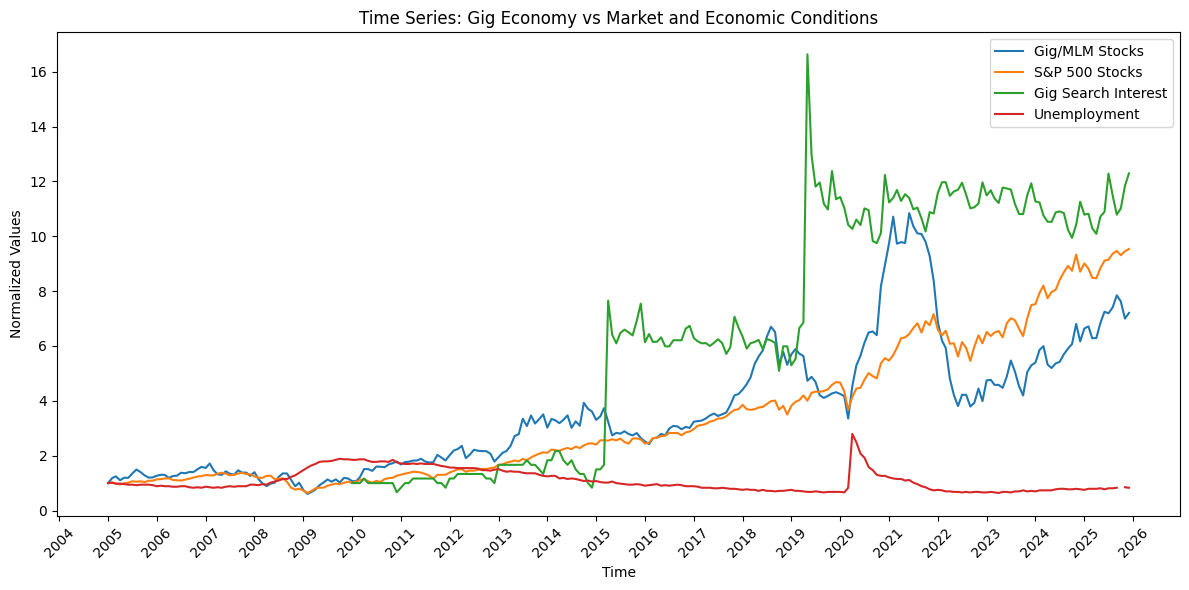

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Make sure you have a datetime column
ts['date'] = pd.to_datetime(ts[['year', 'month']].assign(day=1))  # first day of each month

plt.figure(figsize=(12,6))

plt.plot(ts['date'], ts['Gig_norm'], label='Gig/MLM Stocks')
plt.plot(ts['date'], ts['SP_norm'], label='S&P 500 Stocks')
plt.plot(ts['date'], ts['Search_norm'], label='Gig Search Interest')
plt.plot(ts['date'], ts['Unemployment_norm'], label='Unemployment')

# Format x-axis to show only every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year

plt.legend()
plt.title('Time Series: Gig Economy vs Market and Economic Conditions')
plt.xlabel('Time')
plt.ylabel('Normalized Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()